# Univariate Analysis

**Univariate** means looking at **one column at a time**.

I want to understand the shape and spread of each column before building my model.
I will check numerical columns with histograms and categorical columns with bar charts.

# Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

# finding project root
BASE_DIR = Path(os.getcwd())
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

# loading the cleaned merged file from notebook 02
df = pd.read_csv(BASE_DIR / "data" / "processed" / "flights_merged.csv")

print("Rows:", len(df), "| Columns:", df.shape[1])
df.head(3)

Rows: 271888 | Columns: 12


,userCode,origin,destination,flightType,price,time,distance,agency,date,company,gender,age
0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,4You,male,21
1,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,4You,male,21
2,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,4You,male,21


Data loaded successfully with all cleaned columns from notebook 02.

## Numerical Columns

Histogram shows how values are spread across a range.
The x-axis is the value, y-axis is how many rows have that value.

### Price (Target Variable)

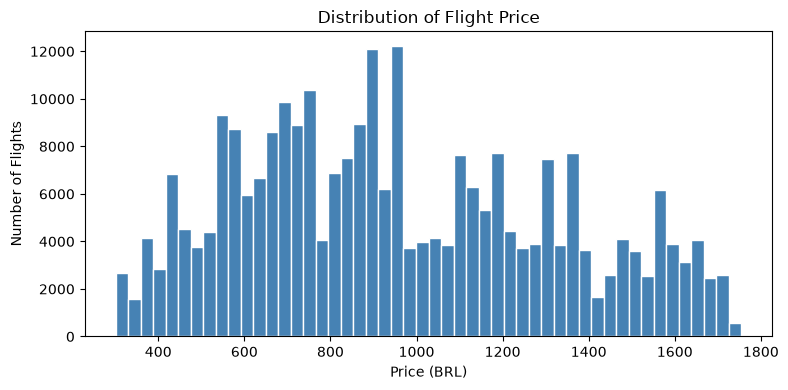

In [2]:
plt.figure(figsize=(8, 4))

# histogram of price — 50 bars, each bar covers a price range
plt.hist(df["price"], bins=50, color="steelblue", edgecolor="white")

plt.title("Distribution of Flight Price")
plt.xlabel("Price (BRL)")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

Price is spread between 300 and 1750, with the highest count of flights sitting around 600–1000 BRL.

C:\Users\Shabareesh\AppData\Local\Temp\ipykernel_15904\2807241891.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["price"], vert=False, patch_artist=True,


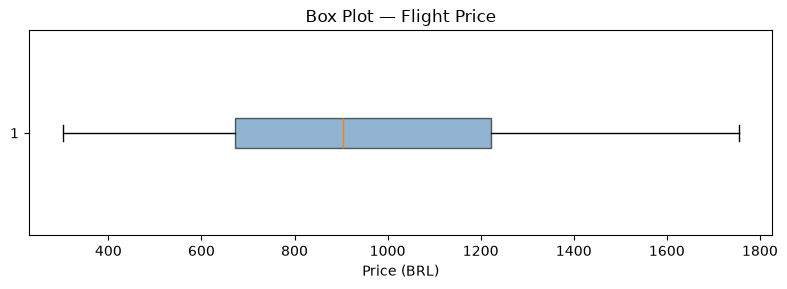

In [3]:
plt.figure(figsize=(8, 3))

# boxplot shows Q1, median, Q3 and any extreme values clearly
plt.boxplot(df["price"], vert=False, patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.6))

plt.title("Box Plot — Flight Price")
plt.xlabel("Price (BRL)")
plt.tight_layout()
plt.show()

The median price sits around 900 BRL and there are no extreme outliers — the box is clean.

### Time (Flight Duration in Hours)

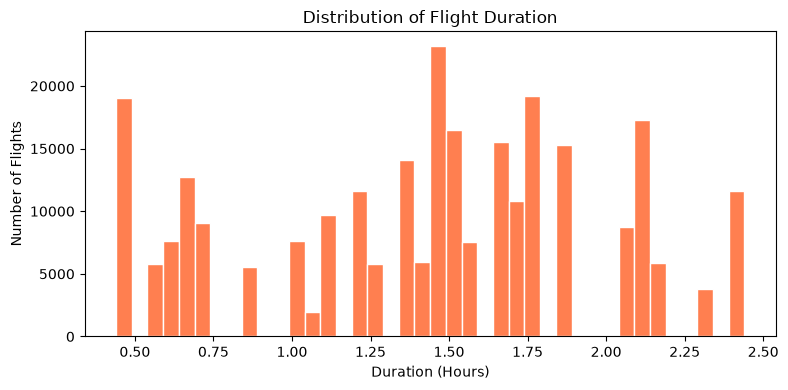

In [4]:
plt.figure(figsize=(8, 4))

plt.hist(df["time"], bins=40, color="coral", edgecolor="white")

plt.title("Distribution of Flight Duration")
plt.xlabel("Duration (Hours)")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

Most flights are under 3 hours, showing this dataset mainly covers domestic or short-haul routes.

### Distance (in KM)

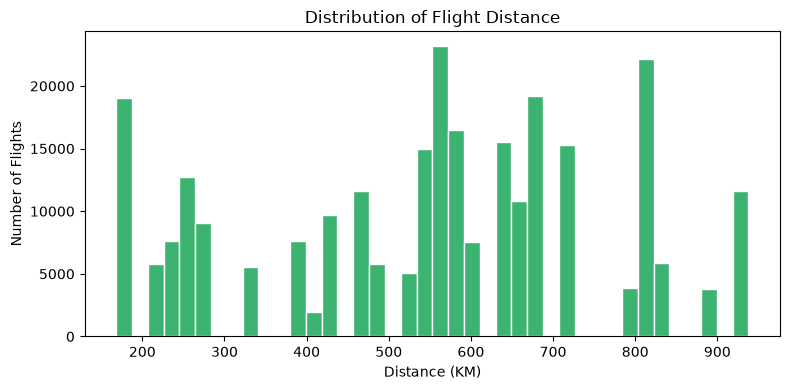

In [5]:
plt.figure(figsize=(8, 4))

plt.hist(df["distance"], bins=40, color="mediumseagreen", edgecolor="white")

plt.title("Distribution of Flight Distance")
plt.xlabel("Distance (KM)")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

Distance is spread fairly wide, with a big group of short routes under 500 km and a long tail for longer routes.

### Age (Traveller Age from users.csv)

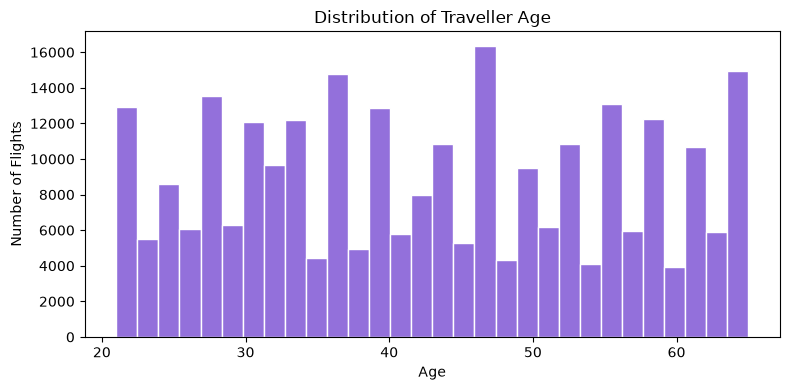

In [6]:
plt.figure(figsize=(8, 4))

plt.hist(df["age"], bins=30, color="mediumpurple", edgecolor="white")

plt.title("Distribution of Traveller Age")
plt.xlabel("Age")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

Travellers are spread across all adult ages from 21 to 65 with no single dominant age group.

## Categorical Columns

Bar charts show how many rows belong to each category.
This helps me see if the data is balanced or if one category dominates.

### Flight Type

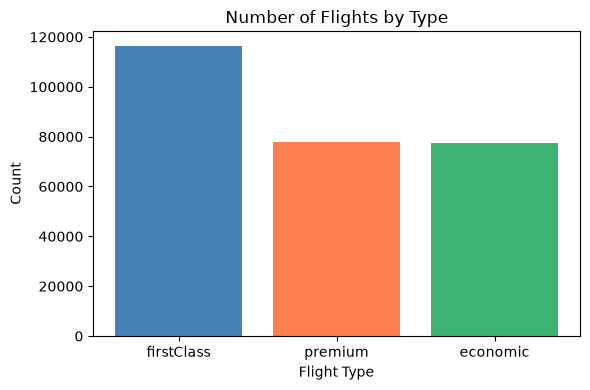

flightType
firstClass    116418
premium        78004
economic       77466
Name: count, dtype: int64


In [7]:
# counting how many flights belong to each flight type
counts = df["flightType"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(counts.index, counts.values, color=["steelblue", "coral", "mediumseagreen"])

plt.title("Number of Flights by Type")
plt.xlabel("Flight Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# printing exact numbers
print(counts)

All three flight types (economic, premium, firstClass) have a similar number of bookings the data is balanced.

### Travel Agency

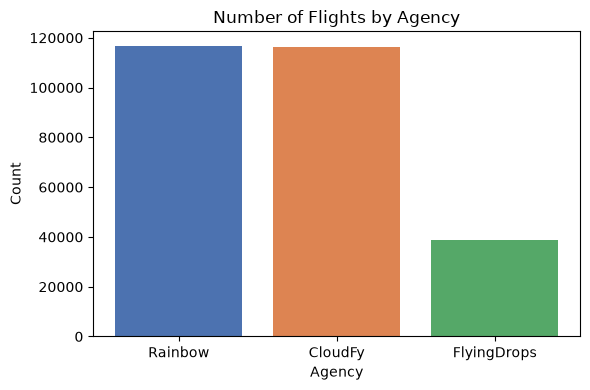

agency
Rainbow        116752
CloudFy        116378
FlyingDrops     38758
Name: count, dtype: int64


In [8]:
counts = df["agency"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452", "#55A868"])

plt.title("Number of Flights by Agency")
plt.xlabel("Agency")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(counts)

All three agencies handle roughly equal booking volumes no single agency dominates the dataset.

### Gender

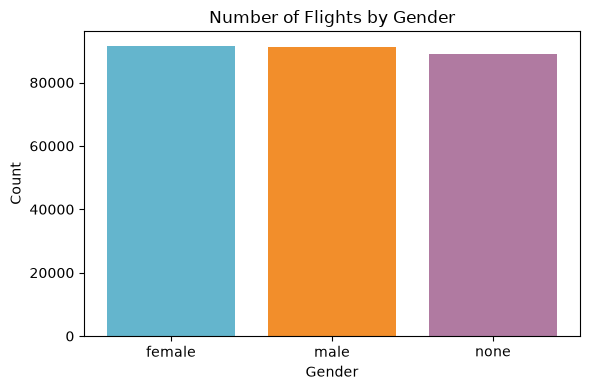

gender
female    91580
male      91248
none      89060
Name: count, dtype: int64


In [9]:
counts = df["gender"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(counts.index, counts.values, color=["#64B5CD", "#F28E2B", "#B07AA1"])

plt.title("Number of Flights by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(counts)

Male and female travellers are roughly equal; 'none' means the user chose not to specify it is not missing data.

### Company

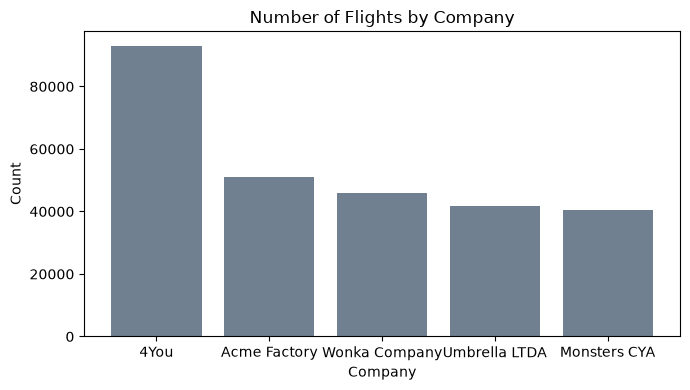

company
4You             92986
Acme Factory     50944
Wonka Company    45882
Umbrella LTDA    41596
Monsters CYA     40480
Name: count, dtype: int64


In [10]:
counts = df["company"].value_counts()

plt.figure(figsize=(7, 4))

plt.bar(counts.index, counts.values, color="slategray")

plt.title("Number of Flights by Company")
plt.xlabel("Company")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(counts)

All 5 companies have a similar number of employees travelling no single company is over-represented.

## Summary

| Column | Type | Key Finding |
|---|---|---|
| `price` | Numerical | Range 300–1750, peak near 900, no outliers |
| `time` | Numerical | Mostly under 3 hours — short routes |
| `distance` | Numerical | Wide spread, heavy on short distances |
| `age` | Numerical | Evenly spread between 21 and 65 |
| `flightType` | Categorical | Balanced across 3 classes |
| `agency` | Categorical | Balanced across 3 agencies |
| `gender` | Categorical | Roughly equal male and female |
| `company` | Categorical | Balanced across 5 companies |